# Data Generation
This code generates an image dataset of a localized gaussian that moves in a 2D space, this example is especially hard for Autoencoders because of the localized behavior. 

In [1]:
import numpy as np

D = 64  # Dimension of the domain
Ntr = 800  # Number of training samples
Nte = 200  # Number of test samples
sigma = 0.2

def gaussian_2d(x, y, x0, y0, sigma):
    return np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))

x = np.linspace(-1, 1, D)
y = np.linspace(-1, 1, D)
X, Y = np.meshgrid(x, y)
# Create training data
train_data = []
x0_vals = np.linspace(-0.5, 0.5, int(np.sqrt(Ntr))+1)
y0_vals = np.linspace(-0.5, 0.5, int(np.sqrt(Ntr))+1)
x0_mesh, y0_mesh = np.meshgrid(x0_vals, y0_vals)
x0_mesh = x0_mesh.flatten()
y0_mesh = y0_mesh.flatten()

for i in range(Ntr):
    train_data.append(gaussian_2d(X, Y, x0_mesh[i], y0_mesh[i], sigma))
train_data = np.stack(train_data, axis=-1)

# Create test data
x0_vals_test = np.random.uniform(-0.5, 0.5, Nte)
y0_vals_test = np.random.uniform(-0.5, 0.5, Nte)
x0_mesh_test = x0_vals_test
y0_mesh_test = y0_vals_test

test_data = []
for i in range(Nte):
    test_data.append(gaussian_2d(X, Y, x0_mesh_test[i], y0_mesh_test[i], sigma))
test_data = np.stack(test_data, axis=-1)

# Normalize the data
train_data = (train_data - np.mean(train_data)) / np.std(train_data)
test_data = (test_data - np.mean(test_data)) / np.std(test_data)
# Split the data into training and test sets
x_train = np.expand_dims(train_data, 0)
x_test = np.expand_dims(test_data, 0)
y_train = np.expand_dims(train_data, 0)
y_test = np.expand_dims(test_data, 0)
p_train = np.stack([x0_mesh, y0_mesh], axis=-1)
p_test = np.stack([x0_mesh_test, y0_mesh_test], axis=-1)

x_train = np.moveaxis(x_train, -1, 0)  # permute to (Ntr x ...)
x_test = np.moveaxis(x_test, -1, 0)    #
y_train = np.moveaxis(y_train, -1, 0)  # permute to (Ntr x ...)
y_test = np.moveaxis(y_test, -1, 0)    #
p_train = np.moveaxis(p_train, 1, 0)  # permute to (Ntr x P)
p_test = np.moveaxis(p_test, 1, 0)    #

# The shape of the data is (N x C x H x W) where:
# N is the number of samples, 
# C is the number of channels, 
# H is the height, and 
# W is the width of the images.

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (800, 1, 64, 64)
x_test shape: (200, 1, 64, 64)
y_train shape: (800, 1, 64, 64)
y_test shape: (200, 1, 64, 64)


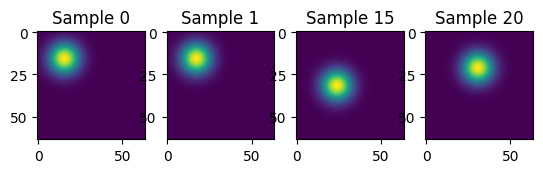

In [2]:
# Showing examples of the data
import matplotlib.pyplot as plt
plt.subplot(1, 4, 1)
plt.imshow(x_train[0, 0, :, :], cmap='viridis')
plt.title('Sample 0')
plt.subplot(1, 4, 2)
plt.imshow(x_train[1, 0, :, :], cmap='viridis')
plt.title('Sample 1')
plt.subplot(1, 4, 3)
plt.imshow(x_test[15, 0, :, :], cmap='viridis')
plt.title('Sample 15')
plt.subplot(1, 4, 4)
plt.imshow(x_test[20, 0, :, :], cmap='viridis')
plt.title('Sample 20')
plt.show()

In [3]:
# Saving the data to anumpy file
np.savez('generated_data.npz', x_train=x_train, x_test=x_test, y_train=y_train, y_test=y_test)